In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [2]:
def modelo1(t, c):
    # Parameters for Reactor 1
    V1 = 200; F0 = 300
    k11 = 4; k12 = 4
    k21 = 3.2; k22 = 3.2
    CAf = 0.5
    
    # Mass balance for compound A in Reactor 1
    dc1 = F0/V1*(CAf - c[0]) - (k11 + k21)*c[0]
    dc2 = -F0/V1*c[1] + k11*c[0]
    dc3 = -F0/V1*c[2] + k21*c[0]
    return [dc1, dc2, dc3]

def modelo2(t, c, C1lag):
    # Parameters for Reactor 2
    V2 = 300; F0 = 300
    k12 = 4; k22 = 3.2
    CAf = 0.5; D = 0.1  # 1/h

    # Conditions before and after the delay
    if t - D > 0:
        CA1lag = np.interp(t - D, C1lag[:, 0], C1lag[:, 1])
        CB1lag = np.interp(t - D, C1lag[:, 0], C1lag[:, 2])
        CC1lag = np.interp(t - D, C1lag[:, 0], C1lag[:, 3])
    else:
        CA1lag = 0
        CB1lag = 0
        CC1lag = 0

    # Mass balance for compound A in Reactor 2
    dc1 = F0/V2*(CA1lag - c[0]) - (k12 + k22)*c[0]
    dc2 = F0/V2*(CB1lag - c[1]) + k12*c[0]
    dc3 = F0/V2*(CC1lag - c[2]) + k22*c[0]
    return [dc1, dc2, dc3]

In [3]:
# Initial conditions
c1_inicial = [8.5, 0, 0]
c2_inicial = [1, 0, 0]

# Time range for integration (hours)
time_span = (0, 0.5)
t = np.linspace(0, 0.5, 100)

# Reactor 1 integration
C1 = solve_ivp(modelo1, time_span, c1_inicial, t_eval=t, method='LSODA')
RC1 = np.column_stack((C1.t, C1.y.T))

# Reactor 2 integration
C2 = solve_ivp(modelo2, time_span, c2_inicial, t_eval=t, args=(RC1,), method='LSODA')

# Extract concentration profiles
CA1, CB1, CC1 = C1.y
CA2, CB2, CC2 = C2.y

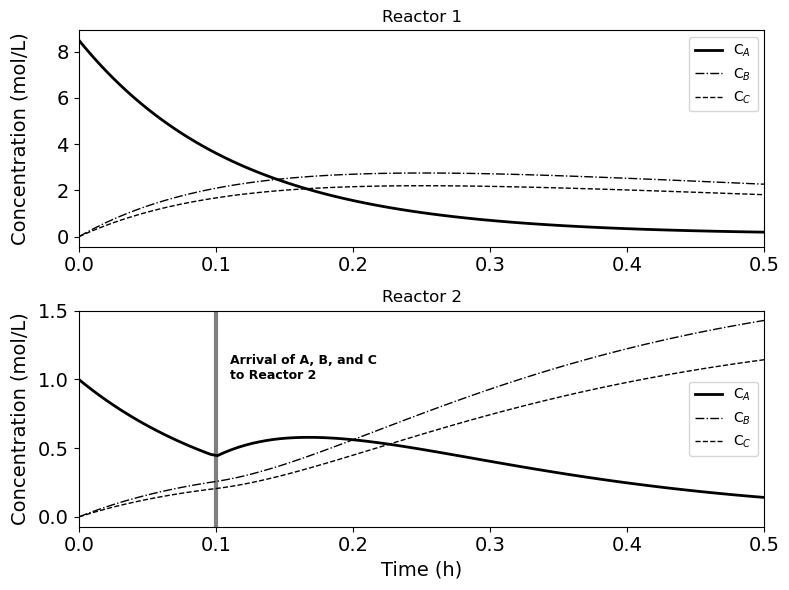

In [4]:
# Plotting
plt.figure(figsize=(8, 6))

plt.subplot(2, 1, 1)
plt.plot(t, CA1, 'k', lw=2, label=r'C$_{A}$')
plt.plot(t, CB1, 'k-.', lw=1, label=r'C$_{B}$')
plt.plot(t, CC1, 'k--', lw=1, label=r'C$_{C}$')
plt.title('Reactor 1')
plt.ylabel('Concentration (mol/L)', fontsize=14, labelpad=20)
plt.xlim(0, 0.5)
plt.tick_params(axis='both', labelsize=14)
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(t, CA2, 'k', lw=2, label=r'C$_{A}$')
plt.plot(t, CB2, 'k-.', lw=1, label=r'C$_{B}$')
plt.plot(t, CC2, 'k--', lw=1, label=r'C$_{C}$')
plt.axvline(x=0.1, color='k', linewidth=3, alpha=0.5)
plt.text(0.11, 1, 'Arrival of A, B, and C\nto Reactor 2', fontsize=9, color='k', weight='bold')
plt.title('Reactor 2')
plt.xlabel('Time (h)', fontsize=14)
plt.xlim(0, 0.5)
plt.ylabel('Concentration (mol/L)', fontsize=14, labelpad=6)
plt.tick_params(axis='both', labelsize=14)
plt.legend()
plt.tight_layout()

plt.show()